<a href="https://colab.research.google.com/github/Ishini01/garment_defect_system/blob/main/Color_Imbalance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Setup

Mounts Google Drive and defines the dataset paths for the Color Imbalance
Detection module (`Balanced/` and `Imbalanced/` subfolders).


In [21]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from google.colab import drive, files

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

drive.mount('/content/drive')

DATASET_PATH = '/content/drive/MyDrive/Garment_Defect_Dataset/raw_images/ColorImbalance/Images'
BALANCED_DIR = os.path.join(DATASET_PATH, 'Balanced')
IMBALANCED_DIR = os.path.join(DATASET_PATH, 'Imbalanced')
valid_ext = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')

print(f"Balanced: {len(os.listdir(BALANCED_DIR))} images")
print(f"Imbalanced: {len(os.listdir(IMBALANCED_DIR))} images")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Balanced: 460 images
Imbalanced: 460 images


## 2. OpenCV Color Analysis

Implements the image processing pipeline for this module:
- **Garment segmentation** — separates the shirt from the background using
  LAB color distance from a sampled border region.
- **Region color statistics** — divides the garment into a 3x3 grid and
  computes the mean LAB color of each cell.
- **Feature extraction** — converts each image into a 14-value engineered
  feature vector (chroma differences, color spread, HSV statistics) that
  is fed into the Random Forest classifier below, rather than raw pixels.


In [22]:
def segment_garment(img_bgr):
    """Separate garment from background by LAB distance from the sampled
    border color - works even when both are near-white/gray."""
    h, w = img_bgr.shape[:2]
    border = max(2, min(h, w) // 40)
    border_pixels = np.concatenate([
        img_bgr[:border, :, :].reshape(-1, 3), img_bgr[-border:, :, :].reshape(-1, 3),
        img_bgr[:, :border, :].reshape(-1, 3), img_bgr[:, -border:, :].reshape(-1, 3),
    ], axis=0)
    bg_color_bgr = np.median(border_pixels, axis=0).astype(np.uint8)

    lab_img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
    bg_lab = cv2.cvtColor(np.uint8([[bg_color_bgr]]), cv2.COLOR_BGR2LAB).astype(np.float32)[0, 0]

    dist = np.sqrt(np.sum((lab_img - bg_lab) ** 2, axis=2))
    dist_u8 = np.clip(dist, 0, 255).astype(np.uint8)

    _, mask = cv2.threshold(dist_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = np.ones((7, 7), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    coverage = np.count_nonzero(mask) / mask.size
    if coverage < 0.05 or coverage > 0.98:
        mask = np.full(dist_u8.shape, 255, dtype=np.uint8)
        coverage = 1.0
    return mask, coverage


def region_lab_means(img_lab, mask, grid=(3, 3)):
    """Mean LAB color of each populated grid cell within the garment mask."""
    h, w = mask.shape
    rows, cols = grid
    means = []
    for r in range(rows):
        for c in range(cols):
            y0, y1 = r * h // rows, (r + 1) * h // rows
            x0, x1 = c * w // cols, (c + 1) * w // cols
            cell_mask = mask[y0:y1, x0:x1]
            cell_lab = img_lab[y0:y1, x0:x1]
            valid = cell_mask > 0
            if np.count_nonzero(valid) < 20:
                continue
            means.append(cell_lab[valid].astype(np.float32).mean(axis=0))
    return np.array(means)


FEATURE_NAMES = [
    'max_delta_e_ab', 'std_L', 'std_a', 'std_b', 'range_L', 'range_a', 'range_b',
    'mean_L', 'mean_a', 'mean_b', 'hue_std', 'sat_mean', 'sat_std', 'mask_coverage',
]


def extract_color_features(image_path, target_size=(224, 224), grid=(3, 3)):
    """Engineered LAB/HSV color feature vector - this is what the Random
    Forest sees, not raw pixels."""
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise ValueError(f"Could not load image: {image_path}")

    img_resized = cv2.resize(img_bgr, target_size)
    mask, coverage = segment_garment(img_resized)

    lab_img = cv2.cvtColor(img_resized, cv2.COLOR_BGR2LAB)
    hsv_img = cv2.cvtColor(img_resized, cv2.COLOR_BGR2HSV)

    region_means = region_lab_means(lab_img, mask, grid)

    if len(region_means) >= 2:
        max_de_ab = 0.0
        for i in range(len(region_means)):
            for j in range(i + 1, len(region_means)):
                d = np.sqrt(np.sum((region_means[i][1:] - region_means[j][1:]) ** 2))
                max_de_ab = max(max_de_ab, d)
        std_L, std_a, std_b = region_means.std(axis=0)
        range_L, range_a, range_b = region_means.max(axis=0) - region_means.min(axis=0)
    else:
        max_de_ab = std_L = std_a = std_b = range_L = range_a = range_b = 0.0

    valid = mask > 0
    if np.count_nonzero(valid) < 20:
        valid = np.ones(mask.shape, dtype=bool)

    mean_L, mean_a, mean_b = lab_img[valid].astype(np.float32).mean(axis=0)
    hue_std = float(hsv_img[:, :, 0][valid].astype(np.float32).std())
    sat_mean = float(hsv_img[:, :, 1][valid].astype(np.float32).mean())
    sat_std = float(hsv_img[:, :, 1][valid].astype(np.float32).std())

    return np.array([
        max_de_ab, std_L, std_a, std_b, range_L, range_a, range_b,
        mean_L, mean_a, mean_b, hue_std, sat_mean, sat_std, coverage,
    ], dtype=np.float32)

print("OpenCV color analysis functions defined.")


OpenCV color analysis functions defined.


## 3. Build the Labeled Dataset

Runs the feature extraction pipeline over every image in the `Balanced/`
and `Imbalanced/` folders, producing the feature matrix `X` and label
vector `y` used for training.


In [23]:
X, y, X_paths = [], [], []
for label, folder in [(0, BALANCED_DIR), (1, IMBALANCED_DIR)]:
    for fname in os.listdir(folder):
        if not fname.lower().endswith(valid_ext):
            continue
        path = os.path.join(folder, fname)
        try:
            X.append(extract_color_features(path))
            y.append(label)
            X_paths.append(path)
        except ValueError as e:
            print(f"Skipped {fname}: {e}")

X, y = np.array(X), np.array(y)
print(f"Dataset: {len(X)} samples ({np.sum(y == 0)} Balanced, {np.sum(y == 1)} Imbalanced)")
print(f"Feature vector size: {X.shape[1]}")


Dataset: 860 samples (400 Balanced, 460 Imbalanced)
Feature vector size: 14


## 4. Train the Random Forest Classifier

Splits the dataset into training (80%) and test (20%) sets, then trains a
`RandomForestClassifier` (200 trees) on the engineered color features.
Reports Accuracy, Precision, Recall, and F1-score on the held-out test set.


In [24]:
X_train, X_test, y_train, y_test, train_paths, test_paths = train_test_split(
    X, y, X_paths, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)} samples, Test: {len(X_test)} samples")

clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    class_weight='balanced',
    random_state=42,
)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

print(f"\nTest Accuracy:  {acc:.2%}")
print(f"Test Precision: {precision:.2%}")
print(f"Test Recall:    {recall:.2%}")
print(f"Test F1-score:  {f1:.2%}")


Train: 688 samples, Test: 172 samples

Test Accuracy:  91.28%
Test Precision: 92.31%
Test Recall:    91.30%
Test F1-score:  91.80%


## 5. Confusion Matrix and Feature Importance

Visualizes classification performance on the test set as a confusion
matrix, and shows which of the 14 engineered features the Random Forest
relied on most for its decisions.


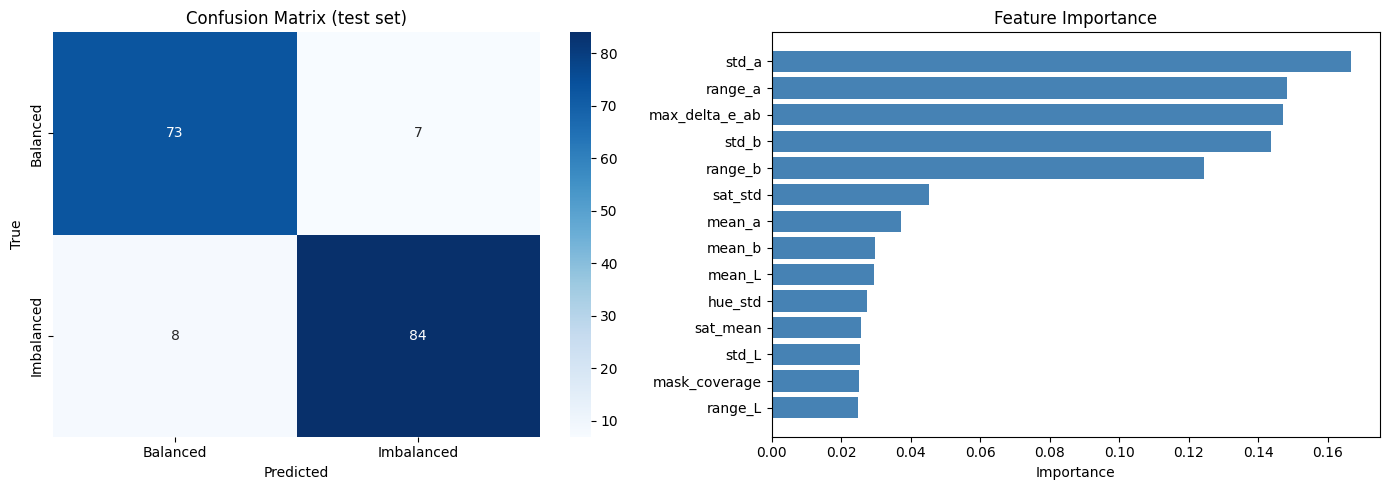

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Balanced', 'Imbalanced'],
            yticklabels=['Balanced', 'Imbalanced'], ax=axes[0])
axes[0].set_title('Confusion Matrix (test set)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

importances = clf.feature_importances_
order = np.argsort(importances)
axes[1].barh(np.array(FEATURE_NAMES)[order], importances[order], color='steelblue')
axes[1].set_title('Feature Importance')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()


## 6. Learning Curve

Plots training vs. cross-validation accuracy as the training set size
increases. This is the Random Forest equivalent of a training/validation
curve the model has no epochs or loss function to plot against, so
accuracy vs. training-set size is the meaningful analog.


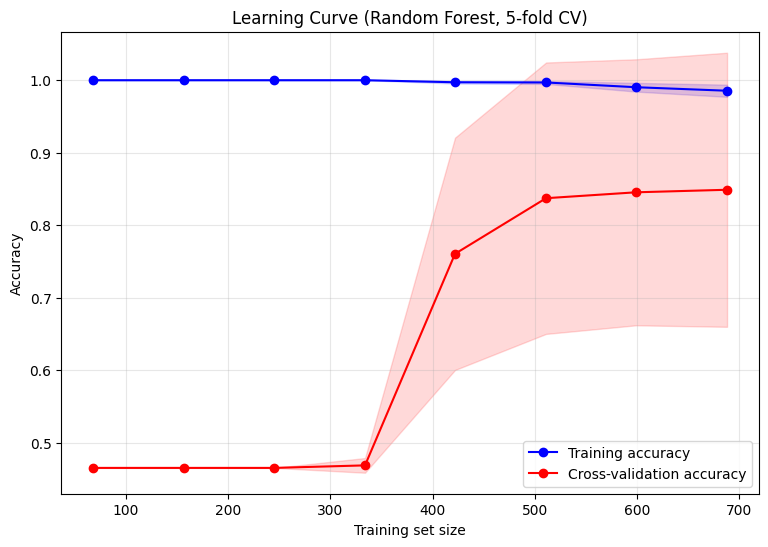

In [26]:
# The RF equivalent of a "training/validation" plot: accuracy at increasing
# training-set sizes, using 5-fold cross-validation instead of epochs
train_sizes, train_scores, val_scores = learning_curve(
    RandomForestClassifier(n_estimators=200, max_depth=8, class_weight='balanced', random_state=42),
    X, y, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 8), random_state=42,
)

train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
val_mean, val_std = val_scores.mean(axis=1), val_scores.std(axis=1)

plt.figure(figsize=(9, 6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training accuracy')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')
plt.plot(train_sizes, val_mean, 'o-', color='red', label='Cross-validation accuracy')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='red')
plt.xlabel('Training set size')
plt.ylabel('Accuracy')
plt.title('Learning Curve (Random Forest, 5-fold CV)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


## 7. Random Forest Convergence (OOB Error)

Plots out-of-bag error against the number of trees in the forest — Random
Forest's own built-in validation signal, showing whether adding more trees
continues to improve the model or has plateaued.


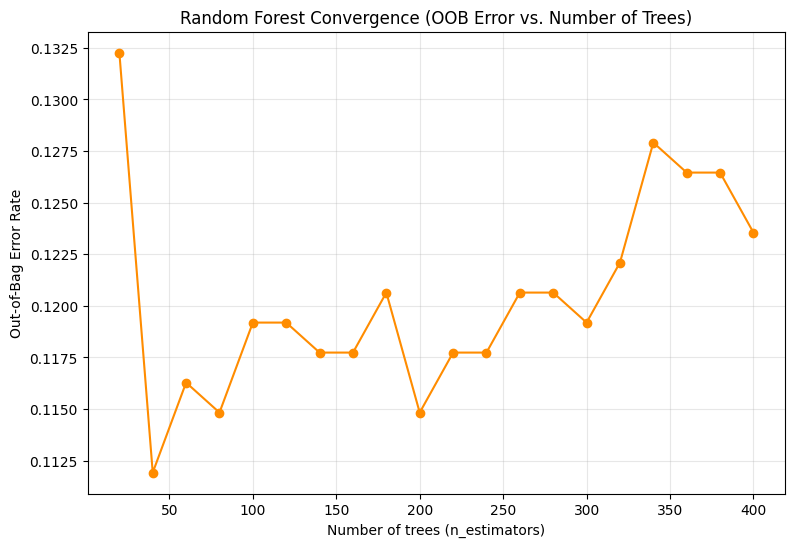

In [27]:
# Random Forest's own built-in validation signal: out-of-bag error as more
# trees are added - the RF-specific analog to a loss-vs-epoch curve
n_estimators_range = range(20, 401, 20)
oob_errors = []

for n in n_estimators_range:
    rf = RandomForestClassifier(n_estimators=n, max_depth=8, class_weight='balanced',
                                 oob_score=True, bootstrap=True, random_state=42)
    rf.fit(X_train, y_train)
    oob_errors.append(1 - rf.oob_score_)

plt.figure(figsize=(9, 6))
plt.plot(list(n_estimators_range), oob_errors, marker='o', color='darkorange')
plt.xlabel('Number of trees (n_estimators)')
plt.ylabel('Out-of-Bag Error Rate')
plt.title('Random Forest Convergence (OOB Error vs. Number of Trees)')
plt.grid(alpha=0.3)
plt.show()


## 8. Save the Trained Model

Persists the trained classifier to Google Drive so it can be reloaded for
inference without retraining.


In [28]:
MODEL_PATH = '/content/drive/MyDrive/Garment_Defect_Dataset/color_imbalance_rf_model.joblib'
joblib.dump(clf, MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")


Model saved to /content/drive/MyDrive/Garment_Defect_Dataset/color_imbalance_rf_model.joblib


## 9. Sample Dataset Images

Displays a random sample of labeled images from both classes, to visually
confirm the dataset looks correct before relying on it.


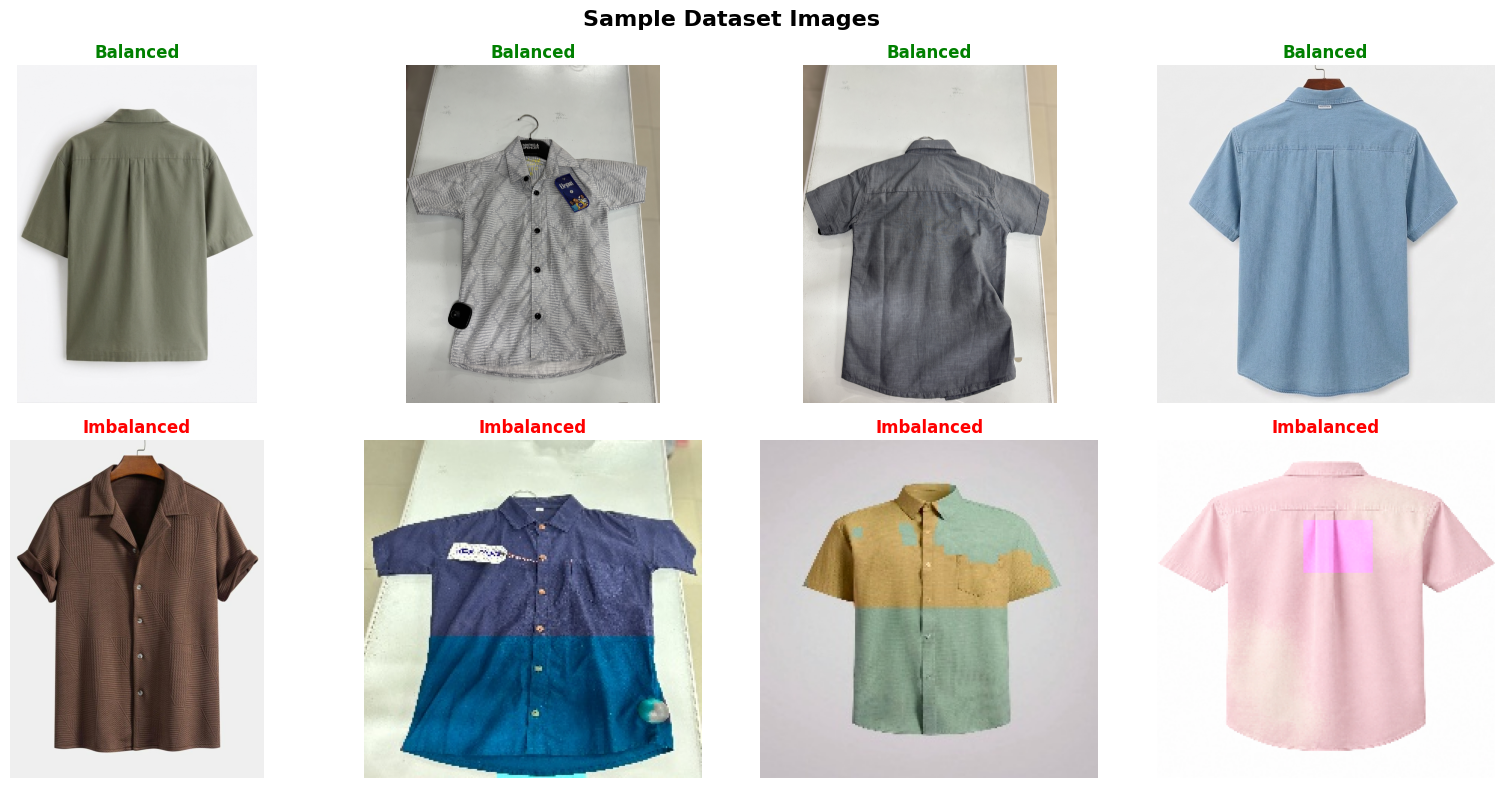

In [29]:
balanced_files = [os.path.join(BALANCED_DIR, f) for f in os.listdir(BALANCED_DIR) if f.lower().endswith(valid_ext)]
imbalanced_files = [os.path.join(IMBALANCED_DIR, f) for f in os.listdir(IMBALANCED_DIR) if f.lower().endswith(valid_ext)]

sample_balanced = random.sample(balanced_files, min(4, len(balanced_files)))
sample_imbalanced = random.sample(imbalanced_files, min(4, len(imbalanced_files)))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, path in zip(axes[0], sample_balanced):
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title("Balanced", color='green', fontsize=12, fontweight='bold')
    ax.axis('off')

for ax, path in zip(axes[1], sample_imbalanced):
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title("Imbalanced", color='red', fontsize=12, fontweight='bold')
    ax.axis('off')

plt.suptitle("Sample Dataset Images", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## 10. Sample Predictions on the Test Set

Shows a random sample of test-set images with their true label vs. the
model's predicted label side by side, so correct and incorrect
predictions can be inspected visually.


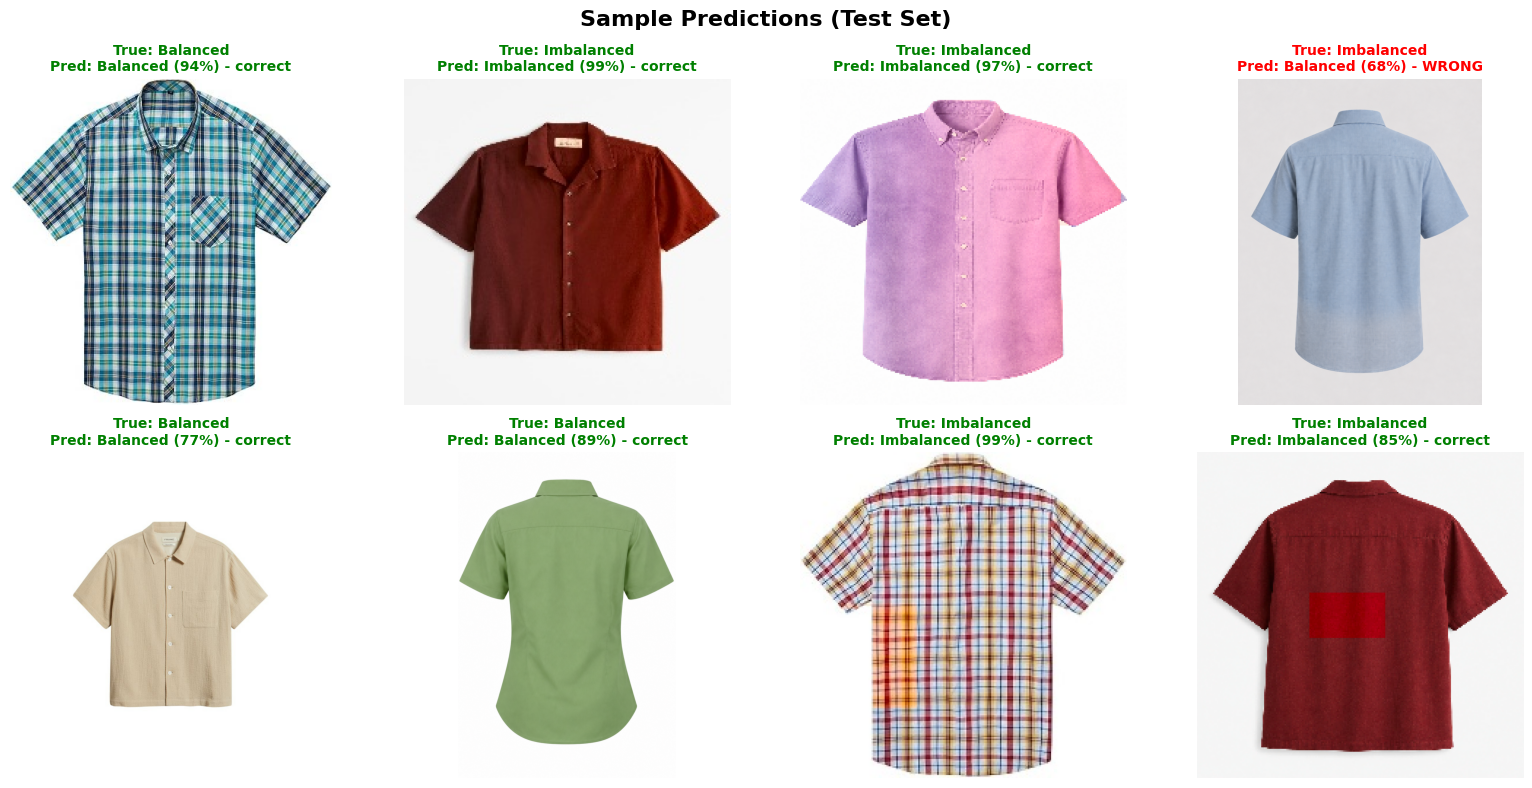

In [30]:
sample_idx = random.sample(range(len(X_test)), min(8, len(X_test)))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, idx in zip(axes.flat, sample_idx):
    path = test_paths[idx]
    true_label = "Imbalanced" if y_test[idx] == 1 else "Balanced"
    pred_label = "Imbalanced" if y_pred[idx] == 1 else "Balanced"
    proba = clf.predict_proba([X_test[idx]])[0]
    confidence = proba[y_pred[idx]]

    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    ax.imshow(img)

    correct = (true_label == pred_label)
    color = 'green' if correct else 'red'
    mark = "correct" if correct else "WRONG"
    ax.set_title(f"True: {true_label}\nPred: {pred_label} ({confidence:.0%}) - {mark}",
                 color=color, fontsize=10, fontweight='bold')
    ax.axis('off')

plt.suptitle("Sample Predictions (Test Set)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## 11. Inference on a New Image

Uploads a new shirt image and runs the trained model on it, displaying the
image together with the predicted status (Balanced/Imbalanced) and
confidence score.


Saving ChatGPT Image Aug 31, 2026, 07_51_28 PM.png to ChatGPT Image Aug 31, 2026, 07_51_28 PM (1).png
Prediction: DEFECT
Confidence: 91.56%


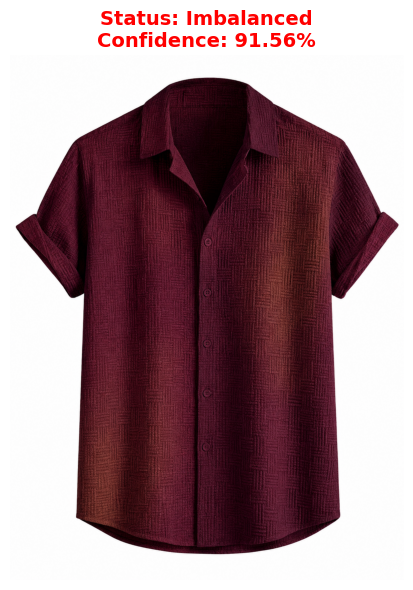

In [32]:
class ColorImbalanceRFClassifier:
    """Color Imbalance Detection Model (Random Forest variant).
    OpenCV/NumPy LAB+HSV feature extraction feeding a trained
    RandomForestClassifier for the final decision.
    """
    def __init__(self, model_path, target_size=(224, 224), grid=(3, 3)):
        self.model = joblib.load(model_path)
        self.target_size = target_size
        self.grid = grid

    def analyze(self, image_path):
        features = extract_color_features(image_path, self.target_size, self.grid)
        pred = self.model.predict([features])[0]
        proba = self.model.predict_proba([features])[0]
        return {
            "defect_type": "Color Imbalance",
            "defect_status": "DEFECT" if pred == 1 else "PASS",
            "confidence": round(float(proba[pred]), 4),
        }


rf_analyzer = ColorImbalanceRFClassifier(MODEL_PATH)

uploaded = files.upload()
image_path = list(uploaded.keys())[0]
result = rf_analyzer.analyze(image_path)

print(f"Prediction: {result['defect_status']}")
print(f"Confidence: {result['confidence']:.2%}")

# Display the uploaded shirt image with the prediction as the title
img_rgb = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img_rgb)
color = 'red' if result['defect_status'] == 'DEFECT' else 'green'
status_label = 'Imbalanced' if result['defect_status'] == 'DEFECT' else 'Balanced'
ax.set_title(f"Status: {status_label}\nConfidence: {result['confidence']:.2%}",
             color=color, fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()
